# Projeto: Análise de Saúde Mental em Gamers

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('Gaming and Mental Health.csv')

print("Colunas do Dataset:")
print(df.columns.tolist())

df.head()


Colunas do Dataset:
['record_id', 'age', 'gender', 'daily_gaming_hours', 'game_genre', 'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance', 'grades_gpa', 'work_productivity_score', 'mood_state', 'mood_swing_frequency', 'withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems', 'eye_strain', 'back_neck_pain', 'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score', 'face_to_face_social_hours_weekly', 'monthly_game_spending_usd', 'years_gaming', 'gaming_addiction_risk_level']


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [ ]:
print(" Informações do Dataset ")
df.info()

print("\n Valores Faltantes ")
print(df.isnull().sum()[df.isnull().sum() > 0])

 Informações do Dataset 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-nul

In [ ]:
df.fillna(0, inplace=True)

print(f"Total de valores nulos após a limpeza: {df.isnull().sum().sum()}")

df[['grades_gpa', 'work_productivity_score']].head()

Total de valores nulos após a limpeza: 0


,grades_gpa,work_productivity_score
0,1.25,0.0
1,3.75,2.0
2,0.00,9.0
3,1.62,2.0
4,2.44,0.0


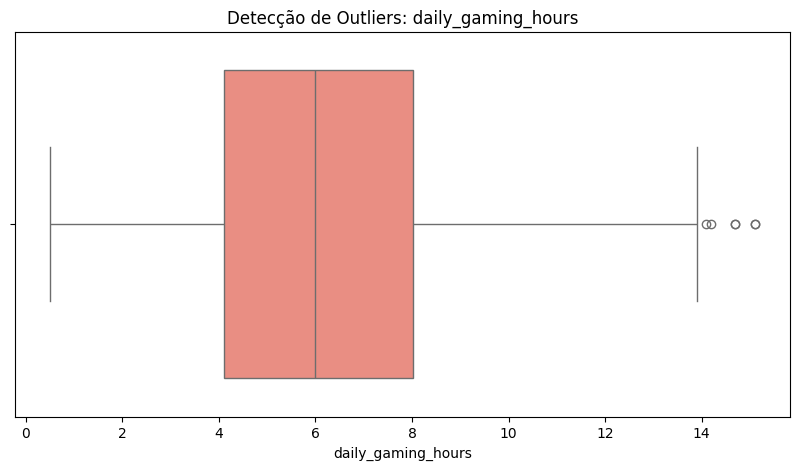

Limite Superior (Corte): 13.91 horas
Quantidade de outliers detectados: 6


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

coluna_alvo = 'daily_gaming_hours'

if coluna_alvo in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[coluna_alvo], color='salmon')
    plt.title(f'Detecção de Outliers: {coluna_alvo}')
    plt.show()

    Q1 = df[coluna_alvo].quantile(0.25)
    Q3 = df[coluna_alvo].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[coluna_alvo] < limite_inferior) | (df[coluna_alvo] > limite_superior)]
    print(f"Limite Superior (Corte): {limite_superior:.2f} horas")
    print(f"Quantidade de outliers detectados: {len(outliers)}")
else:
    print(f"Erro: A coluna '{coluna_alvo}' não foi encontrada.")

In [ ]:
df_limpo = df[df['daily_gaming_hours'] <= limite_superior].copy()

print(f"Linhas antes: {len(df)}")
print(f"Linhas após removeção os outliers: {len(df_limpo)}")
print("Outliers removidos com sucesso!")

Linhas antes: 1000
Linhas após removeção os outliers: 994
Outliers removidos com sucesso!


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['gender_n'] = le.fit_transform(df['gender'])
df['mood_state_n'] = le.fit_transform(df['mood_state'])

risco_map = {'Low': 0, 'Moderate': 1, 'High': 2, 'Severe': 3}
df['risk_level_n'] = df['gaming_addiction_risk_level'].map(risco_map)

print("Conversão de categorias concluída!")
df[['gender', 'gender_n', 'gaming_addiction_risk_level', 'risk_level_n']].head()

Conversão de categorias concluída!


,gender,gender_n,gaming_addiction_risk_level,risk_level_n
0,Male,1,Severe,3
1,Male,1,Low,0
2,Male,1,Severe,3
3,Female,0,High,2
4,Male,1,Moderate,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_para_escalar = ['age', 'daily_gaming_hours', 'sleep_hours', 'weight_change_kg', 'monthly_game_spending_usd', 'years_gaming']

df_limpo[cols_para_escalar] = scaler.fit_transform(df_limpo[cols_para_escalar])

print("Dados normalizados com sucesso (escala de 0 a 1)!")
df_limpo[cols_para_escalar].head()

Dados normalizados com sucesso (escala de 0 a 1)!


,age,daily_gaming_hours,sleep_hours,weight_change_kg,monthly_game_spending_usd,years_gaming
0,0.181818,0.791045,0.116667,0.764045,0.768476,0.105263
1,0.363636,0.186567,0.700000,0.044944,0.093235,0.000000
2,0.454545,0.529851,0.233333,0.202247,0.201755,0.263158
3,0.318182,0.500000,0.350000,0.022472,0.103171,0.315789
4,0.227273,0.470149,0.066667,0.056180,0.065048,0.000000


In [ ]:
cols_bool = ['withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems',
             'eye_strain', 'back_neck_pain']

for col in cols_bool:
    df_limpo[col] = df_limpo[col].astype(int)

mapa_sono = {'Very Poor': 0, 'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
mapa_freq = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Daily': 4}
mapa_performance = {'Poor': 0, 'Below Average': 1, 'Average': 2, 'Good': 3, 'Excellent': 4}

df_limpo['sleep_quality_n'] = df_limpo['sleep_quality'].map(mapa_sono)
df_limpo['sleep_disruption_n'] = df_limpo['sleep_disruption_frequency'].map(mapa_freq)
df_limpo['academic_performance_n'] = df_limpo['academic_work_performance'].map(mapa_performance)

df_limpo.drop(columns=['sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance'], inplace=True)

print("Conversões concluídas!")
df_limpo[cols_bool + ['sleep_quality_n', 'academic_performance_n']].head()

Conversões concluídas!


,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,sleep_quality_n,academic_performance_n
0,1,0,1,1,0,0.0,1.0
1,0,0,0,0,0,2.0,3.0
2,1,1,1,0,1,2.0,0.0
3,1,1,0,1,1,2.0,0.0
4,1,0,0,0,0,1.0,2.0


In [ ]:
cols_para_remover = ['record_id', 'gaming_addiction_risk_level', 'primary_game', 'game_genre', 'gaming_platform', 'mood_swing_frequency']

df_final = df_limpo.drop(columns=cols_para_remover)

print(f"Colunas restantes: {len(df_final.columns)}")

Colunas restantes: 21


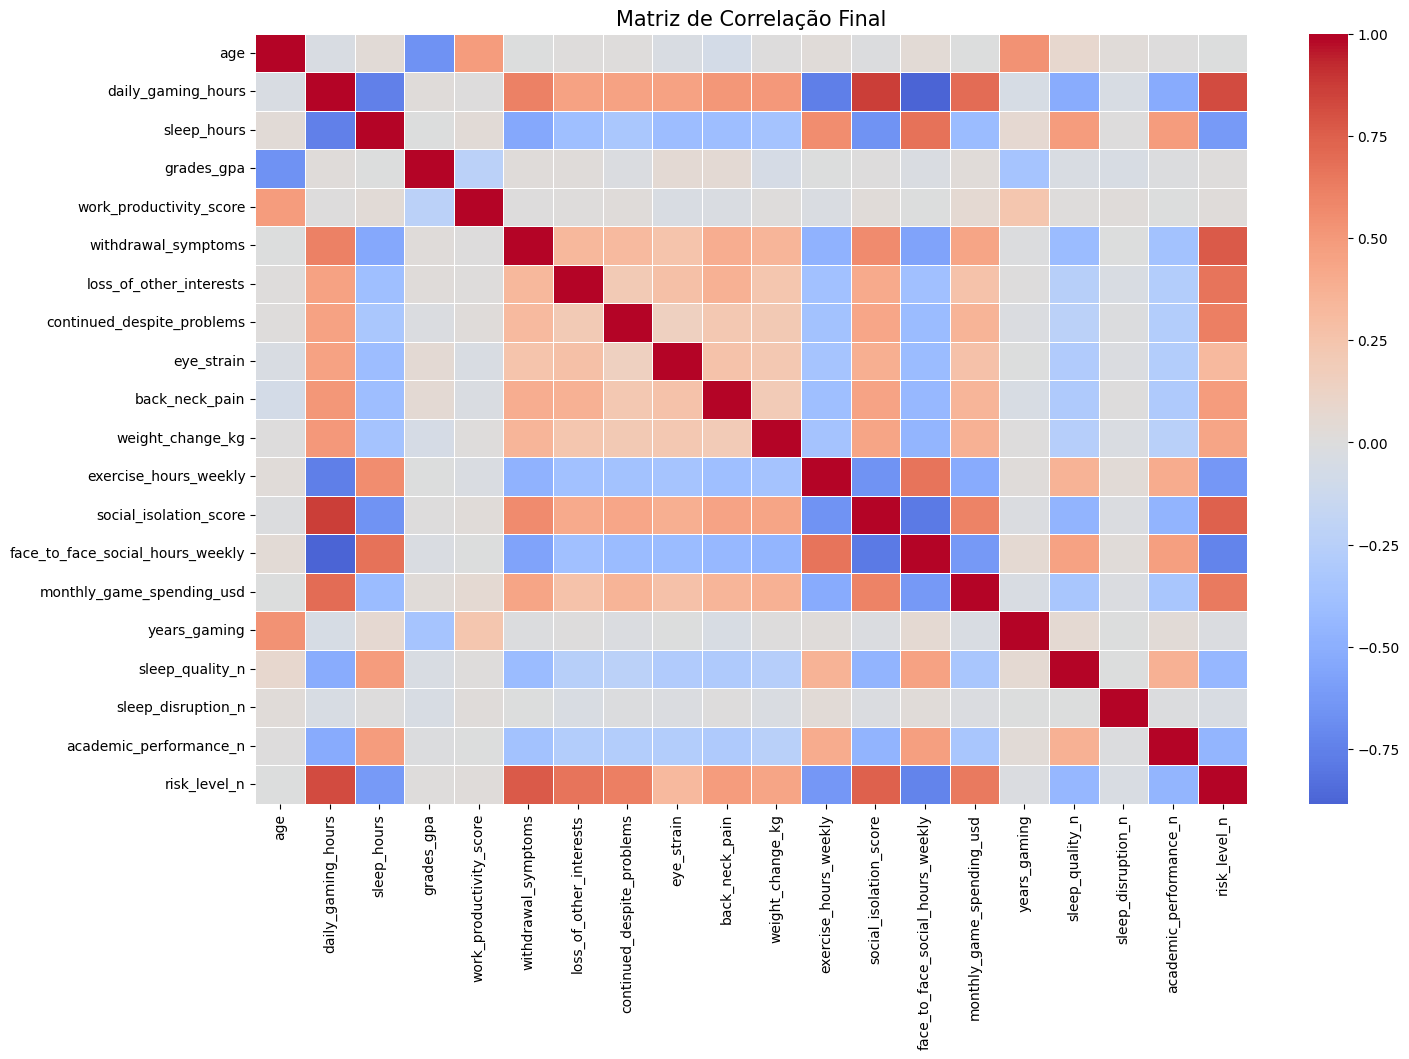


 Sucesso! Ranking de influência no Risco de Vício:
risk_level_n                        1.000000
daily_gaming_hours                  0.816787
withdrawal_symptoms                 0.771706
social_isolation_score              0.744859
loss_of_other_interests             0.665313
monthly_game_spending_usd           0.641454
continued_despite_problems          0.620046
back_neck_pain                      0.487996
weight_change_kg                    0.436139
eye_strain                          0.320830
work_productivity_score             0.014476
grades_gpa                          0.013027
age                                -0.005287
years_gaming                       -0.021864
sleep_disruption_n                 -0.033385
sleep_quality_n                    -0.448265
academic_performance_n             -0.459598
sleep_hours                        -0.613038
exercise_hours_weekly              -0.635993
face_to_face_social_hours_weekly   -0.730541
Name: risk_level_n, dtype: float64


In [ ]:
mapa_risco = {'Low': 0, 'Moderate': 1, 'High': 2, 'Severe': 3}

if 'risk_level_n' not in df_final.columns:
    if 'gaming_addiction_risk_level' in df_final.columns:
        df_final['risk_level_n'] = df_final['gaming_addiction_risk_level'].map(mapa_risco)
    elif 'gaming_addiction_risk_level' in df.columns:
        df_final['risk_level_n'] = df['gaming_addiction_risk_level'].map(mapa_risco)

df_blindado = df_final.select_dtypes(include=[np.number]).fillna(0)

df_blindado = df_blindado.drop(columns=['record_id'], errors='ignore')

plt.figure(figsize=(16, 10))
correlacao = df_blindado.corr()

sns.heatmap(correlacao, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlação Final', fontsize=15)
plt.show()

if 'risk_level_n' in correlacao.columns:
    print("\n Sucesso! Ranking de influência no Risco de Vício:")
    print(correlacao['risk_level_n'].sort_values(ascending=False))
else:
    print("\n Atenção: A coluna de risco ainda não foi encontrada.")

In [ ]:

colunas_selecionadas = [
    'daily_gaming_hours', 'withdrawal_symptoms', 'social_isolation_score',
    'loss_of_other_interests', 'monthly_game_spending_usd', 'continued_despite_problems',
    'back_neck_pain', 'weight_change_kg', 'eye_strain', 'sleep_quality_n',
    'academic_performance_n', 'sleep_hours', 'exercise_hours_weekly',
    'face_to_face_social_hours_weekly', 'risk_level_n'
]

df_final_enxuto = df_blindado[colunas_selecionadas].copy()

print(f"Dataset pronto! Númeor de colunas atual: {df_final_enxuto.shape[1]}.")
df_final_enxuto.head()

Dataset pronto! Númeor de colunas atual: 15.


,daily_gaming_hours,withdrawal_symptoms,social_isolation_score,loss_of_other_interests,monthly_game_spending_usd,continued_despite_problems,back_neck_pain,weight_change_kg,eye_strain,sleep_quality_n,academic_performance_n,sleep_hours,exercise_hours_weekly,face_to_face_social_hours_weekly,risk_level_n
0,0.791045,1,7,0,0.768476,1,0,0.764045,1,0.0,1.0,0.116667,3.7,1.3,3
1,0.186567,0,2,0,0.093235,0,0,0.044944,0,2.0,3.0,0.700000,8.5,10.7,0
2,0.529851,1,5,1,0.201755,1,1,0.202247,0,2.0,0.0,0.233333,7.1,3.2,3
3,0.500000,1,4,1,0.103171,0,1,0.022472,1,2.0,0.0,0.350000,5.2,9.1,2
4,0.470149,1,4,0,0.065048,0,0,0.056180,0,1.0,2.0,0.066667,6.1,4.5,1


In [ ]:
from sklearn.decomposition import PCA

df_final_enxuto = df_final_enxuto.fillna(0)

X = df_final_enxuto.drop(columns=['risk_level_n'])
y = df_final_enxuto['risk_level_n']

pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(X)

df_pca = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])
df_pca['Risco'] = y.reset_index(drop=True)

print(f"Informação preservada: {sum(pca.explained_variance_ratio_)*100:.2f}%")
print("PCA concluído com sucesso!")

Informação preservada: 83.97%
PCA concluído com sucesso!


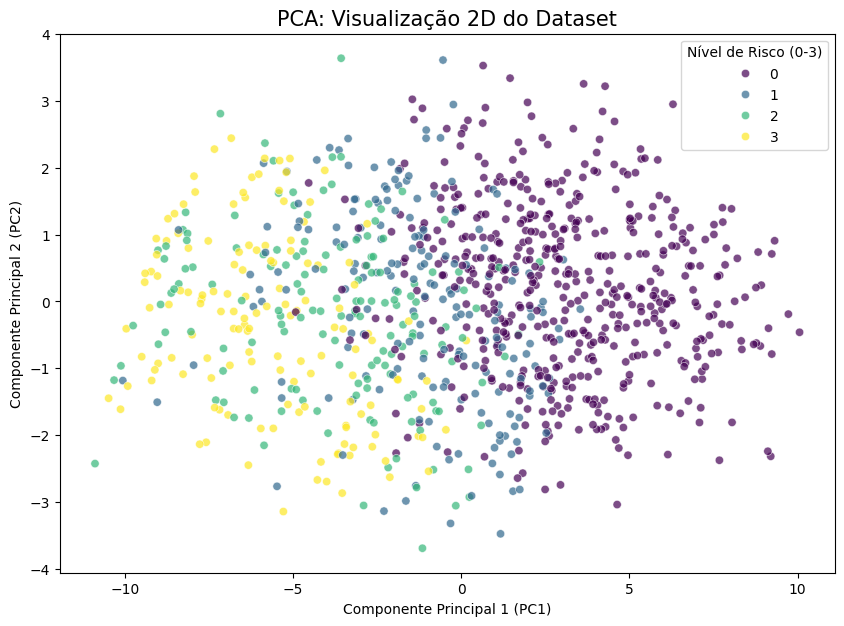

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Risco', palette='viridis', data=df_pca, alpha=0.7)

plt.title('PCA: Visualização 2D do Dataset', fontsize=15)
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.legend(title='Nível de Risco (0-3)')
plt.show()

In [ ]:
df_final_enxuto.to_csv('gaming_mental_health_clean.csv', index=False)
print("Arquivo 'gaming_mental_health_clean.csv' salvo com sucesso!")

from google.colab import files
files.download('gaming_mental_health_clean.csv')

Arquivo 'gaming_mental_health_clean.csv' salvo com sucesso!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>